[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maierav/ffa-ppa-public-domain/blob/main/ffa_ppa_public_domain.ipynb)

# Public-domain images of the FFA and PPA

This notebook builds figures showing the location of the **fusiform face area (FFA)** and the
**parahippocampal place area (PPA)** on a human brain, using only inputs whose license permits
releasing the resulting images into the public domain (CC0).

**Pipeline**

1. Download meta-analytic z-maps for the terms *fusiform face* and *place* from [Neurosynth](https://neurosynth.org) (data are CC0).
2. Find the largest suprathreshold cluster in each hemisphere, which isolates the FFA and PPA proper (the full maps also contain OFA, RSC, etc.).
3. Render three kinds of figure per region: MNI slices at the peaks, a 3D "glass brain" isosurface, and an inflated cortical surface projection.

**Licenses of everything that touches the output**

| Input / tool | License | Note |
|---|---|---|
| Neurosynth term maps | CC0 | downloaded below via the Neurosynth API |
| fsaverage surfaces (via Nilearn) | FreeSurfer license | free to use; the rendered image is your own work |
| MNI152 template (via Nilearn) | MNI permissive notice | free use, copy, modify, distribute |
| Nilearn, nibabel, scikit-image, plotly, matplotlib | BSD / MIT | tools only, no claim on outputs |

Runs on Colab or locally (Python 3.10+). Outputs are written to `OUT_DIR` (defaults to `/content/ffa_ppa` on Colab, `./ffa_ppa_output` elsewhere).


In [1]:
# --- Setup: install pinned dependencies if missing (needed on Colab) ---
import importlib, subprocess, sys
need = {"nilearn": "nilearn==0.12.0", "nibabel": "nibabel==5.3.2", "skimage": "scikit-image==0.25.2",
        "plotly": "plotly==5.24.1", "kaleido": "kaleido==0.2.1"}
missing = [pkg for mod, pkg in need.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("all dependencies present")

all dependencies present


In [2]:
import os, json, urllib.request, warnings
import numpy as np, pandas as pd, nibabel as nib
from scipy import ndimage
from skimage import measure
import plotly.graph_objects as go
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from nilearn import datasets, plotting, image
from nilearn.surface import SurfaceImage
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
OUT_DIR = "/content/ffa_ppa" if IN_COLAB else "./ffa_ppa_output"
DATA_DIR = os.path.join(OUT_DIR, "data"); FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)
INTERACTIVE = os.environ.get("FFA_PPA_STATIC") != "1"   # show rotatable plotly figures inline
SURF_MESH = "fsaverage6"   # 'fsaverage5' (fast), 'fsaverage6' (default), 'fsaverage' (high-res, slower, larger files)

# Region definitions: Neurosynth term, analysis id (verified below), threshold on the z map, colors
REGIONS = {
    "FFA": dict(term="fusiform face", analysis_id=917,  thr=6.0, color="#d7301f", ctx_color="#fdae6b", cmap="YlOrRd"),
    "PPA": dict(term="place",         analysis_id=1102, thr=4.0, color="#1f78b4", ctx_color="#a6cee3", cmap="YlGnBu"),
}
print("output dir:", os.path.abspath(OUT_DIR))

output dir: /Users/alexmaier/Documents/ClaudeCode/ffa_ppa_public_domain/ffa_ppa_output


## 1. Fetch the Neurosynth maps

Neurosynth exposes each term as an *analysis* with two images: a **uniformity test** (where do studies mentioning
the term report activation) and an **association test** (where is activation *more likely* in studies mentioning the term than
in those that do not). The association map is the more specific one, so it is what we use. The maps served by the API are
already FDR-thresholded at q = 0.01 (smallest nonzero |z| is about 4), so thresholds below 4 change nothing.

The analysis ids below were looked up on 2026-09-14. The helper verifies the id still points at the expected term and
falls back to a search if not.

In [3]:
NS = "https://neurosynth.org/api"

def _get(url):
    with urllib.request.urlopen(url, timeout=60) as r:
        return json.load(r)

def resolve_term(term, hint_id=None):
    "Return the Neurosynth analysis id for `term`, verifying the hint first."
    if hint_id is not None:
        try:
            a = _get(f"{NS}/analyses/{hint_id}/")["data"]
            if a["name"] == term:
                return hint_id, a["n_studies"]
        except Exception:
            pass
    page = 1
    while page < 200:   # pagination is imperfect on the server; a few terms are only reachable by id
        d = _get(f"{NS}/analyses/?page={page}")
        if not d["data"]:
            break
        for a in d["data"]:
            if a["name"] == term:
                return a["id"], a["n_studies"]
        page += 1
    raise LookupError(f"term {term!r} not found in Neurosynth")

def fetch_association_map(term, hint_id, out_path):
    aid, n_studies = resolve_term(term, hint_id)
    imgs = _get(f"{NS}/analyses/{aid}/images/")["data"]
    assoc = [i for i in imgs if "association" in i["name"]][0]
    if not os.path.exists(out_path):
        urllib.request.urlretrieve("https://neurosynth.org" + assoc["download"], out_path)
    print(f"{term!r}: analysis {aid}, {n_studies} studies, image {assoc['id']} -> {out_path}")
    return nib.load(out_path)

maps = {}
for name, r in REGIONS.items():
    path = os.path.join(DATA_DIR, f"neurosynth_{r['term'].replace(' ', '_')}_association_z.nii.gz")
    maps[name] = fetch_association_map(r["term"], r["analysis_id"], path)

'fusiform face': analysis 917, 143 studies, image 3666 -> ./ffa_ppa_output/data/neurosynth_fusiform_face_association_z.nii.gz


'place': analysis 1102, 189 studies, image 4406 -> ./ffa_ppa_output/data/neurosynth_place_association_z.nii.gz


## 2. Isolate the region: largest cluster per hemisphere

Both maps contain more than the named region (the face map also includes the occipital face area and amygdala,
the place map includes retrosplenial and occipital place areas). The largest suprathreshold cluster in each
hemisphere is the FFA / PPA proper. The peaks land where the literature puts them: FFA around
(±40, −50, −22) and PPA around (±28, −45, −12) in MNI space.

In [4]:
def largest_cluster_per_hemi(img, thr, min_size=50):
    "Boolean mask of the largest cluster (> thr) in each hemisphere, plus a peak table."
    d = img.get_fdata(); lab, n = ndimage.label(d > thr)
    keep = np.zeros_like(d, bool); rows = []
    if n == 0:
        return keep, pd.DataFrame(rows)
    idx = range(1, n + 1)
    sizes = ndimage.sum(np.ones_like(d), lab, index=idx)
    x_mni = [nib.affines.apply_affine(img.affine, c)[0] for c in ndimage.center_of_mass(np.ones_like(d), lab, index=idx)]
    for hemi, sel in (("L", lambda x: x < 0), ("R", lambda x: x > 0)):
        cand = [(sizes[i], i + 1) for i in range(n) if sel(x_mni[i]) and sizes[i] >= min_size]
        if not cand:
            continue
        sz, lbl = max(cand); keep |= lab == lbl
        pk = np.unravel_index(np.argmax(d * (lab == lbl)), d.shape)
        x, y, z = nib.affines.apply_affine(img.affine, pk)
        rows.append(dict(hemi=hemi, voxels=int(sz), vol_cm3=round(sz * 8 / 1000, 1), peak_x=int(x), peak_y=int(y), peak_z=int(z), peak_z_score=round(float(d[pk]), 1)))
    return keep, pd.DataFrame(rows)

masks, peaks = {}, {}
for name, r in REGIONS.items():
    masks[name], peaks[name] = largest_cluster_per_hemi(maps[name], r["thr"])
    nib.save(nib.Nifti1Image(masks[name].astype(np.uint8), maps[name].affine), os.path.join(DATA_DIR, f"{name}_mask_MNI152_2mm.nii.gz"))
    print(f"\n{name}  (term {r['term']!r}, z > {r['thr']})"); display(peaks[name])


FFA  (term 'fusiform face', z > 6.0)


,hemi,voxels,vol_cm3,peak_x,peak_y,peak_z,peak_z_score
0,L,493,3.9,-40,-52,-20,19.7
1,R,1969,15.8,42,-50,-24,24.1



PPA  (term 'place', z > 4.0)


,hemi,voxels,vol_cm3,peak_x,peak_y,peak_z,peak_z_score
0,L,481,3.8,-28,-46,-10,11.1
1,R,361,2.9,28,-44,-14,8.5


## 3. MNI slice views at the peaks

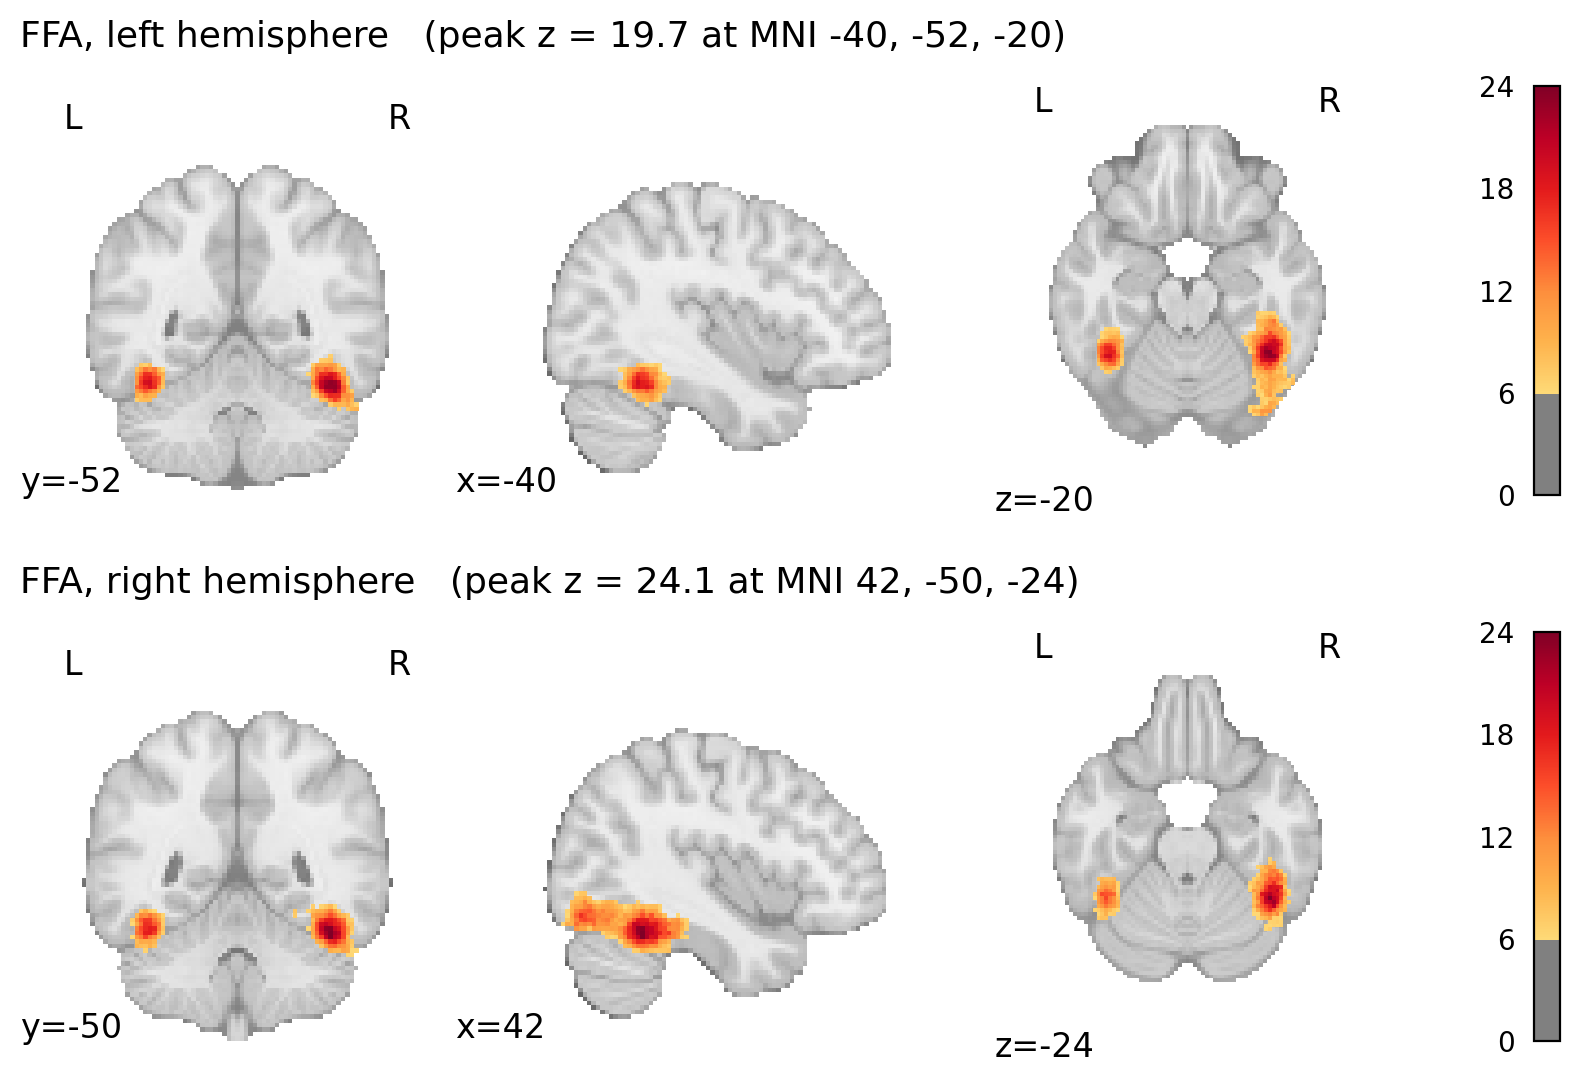

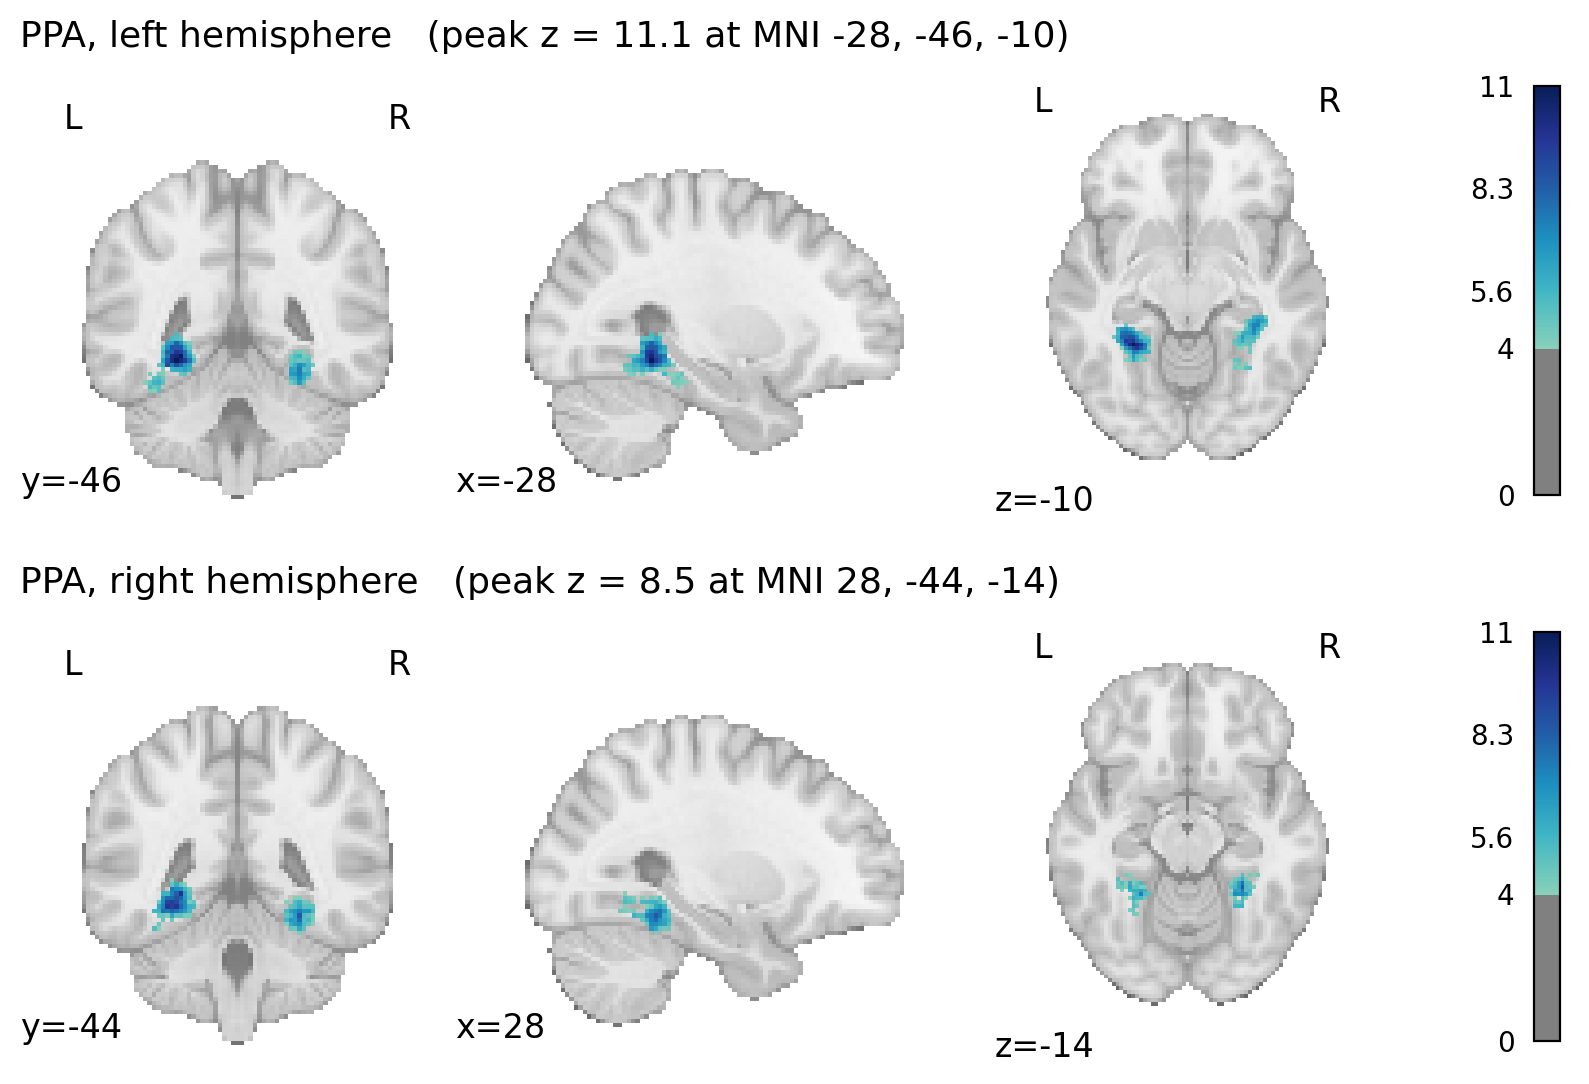

In [5]:
for name, r in REGIONS.items():
    img = maps[name]; masked = image.math_img("a * m", a=img, m=nib.Nifti1Image(masks[name].astype(np.uint8), img.affine))
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.5))
    for ax, (_, row) in zip(axes, peaks[name].iterrows()):
        plotting.plot_stat_map(masked, cut_coords=(row.peak_x, row.peak_y, row.peak_z), threshold=r["thr"], cmap=r["cmap"],
                               vmax=float(img.get_fdata().max()), draw_cross=False, axes=ax, colorbar=True)
        ax.text(0.0, 1.02, f"{name}, {'left' if row.hemi == 'L' else 'right'} hemisphere   (peak z = {row.peak_z_score} at MNI {row.peak_x}, {row.peak_y}, {row.peak_z})",
                transform=ax.transAxes, fontsize=13, ha="left", va="bottom")
    out = os.path.join(FIG_DIR, f"{name}_mni_slices.png")
    fig.savefig(out, dpi=200, bbox_inches="tight", facecolor="white"); plt.close(fig)
    display(Image(out, width=800))

## 4. 3D glass-brain isosurface

The region mask is smoothed slightly, converted to a triangle mesh with marching cubes, and drawn inside a translucent
pial surface (fsaverage5). Other suprathreshold clusters from the same map are shown faintly for context in a second version.
The figures are written as PNG (ventral and oblique views) and as self-contained HTML that can be rotated in a browser.

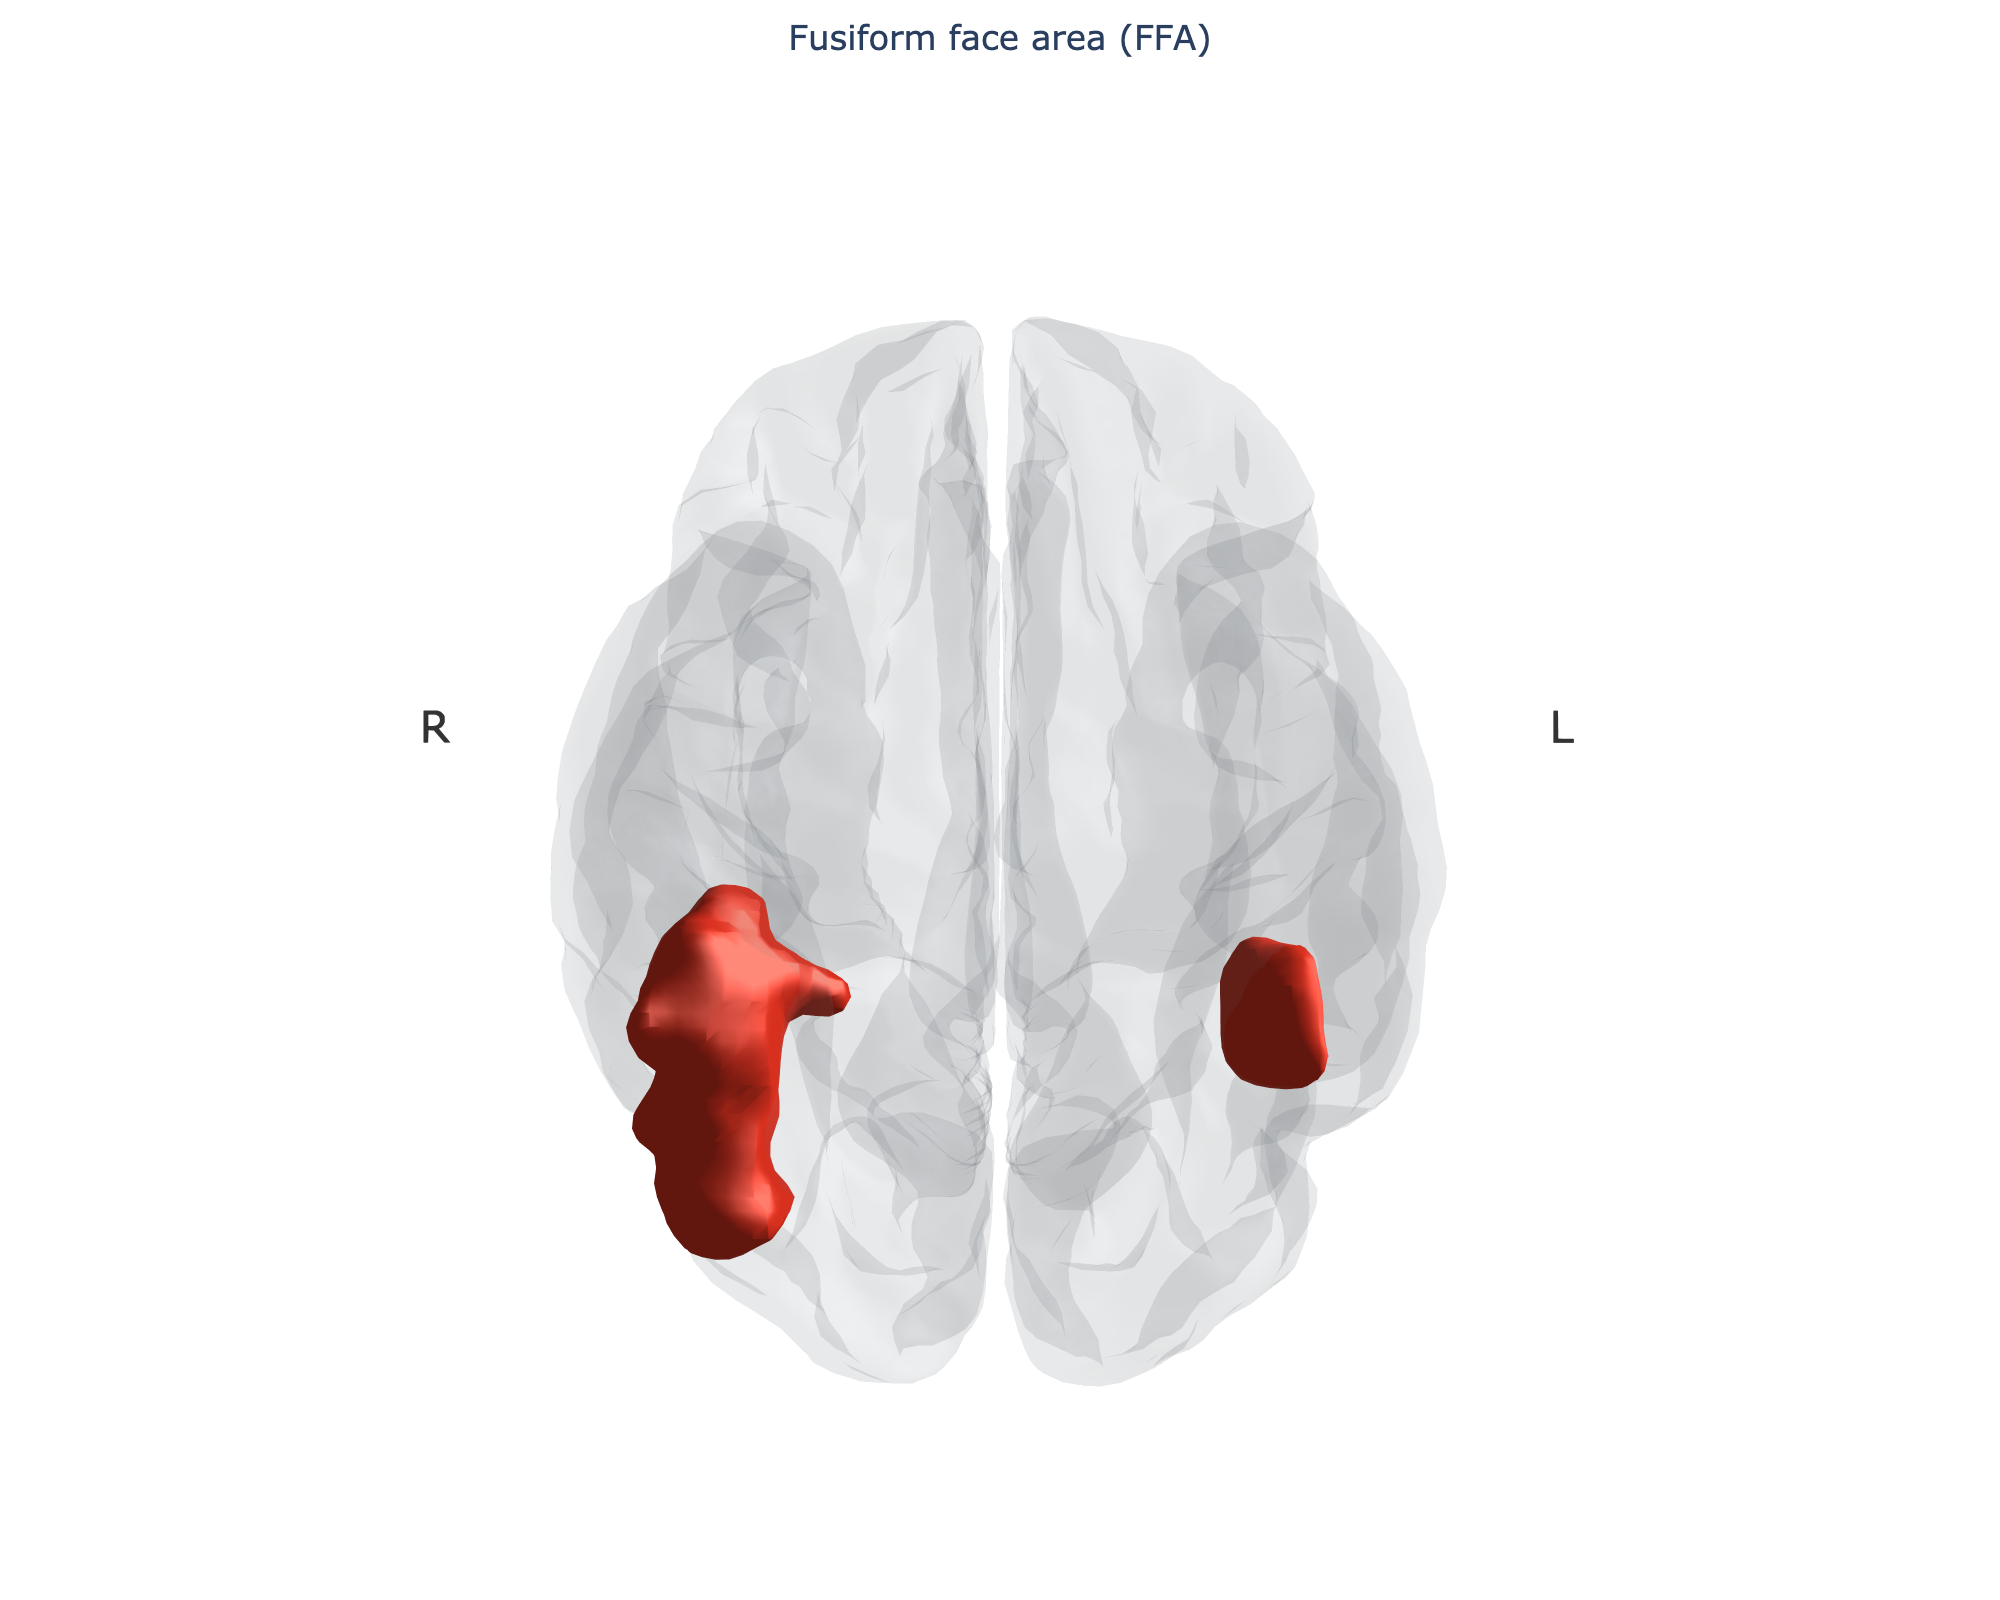

FFA glass-brain figures written


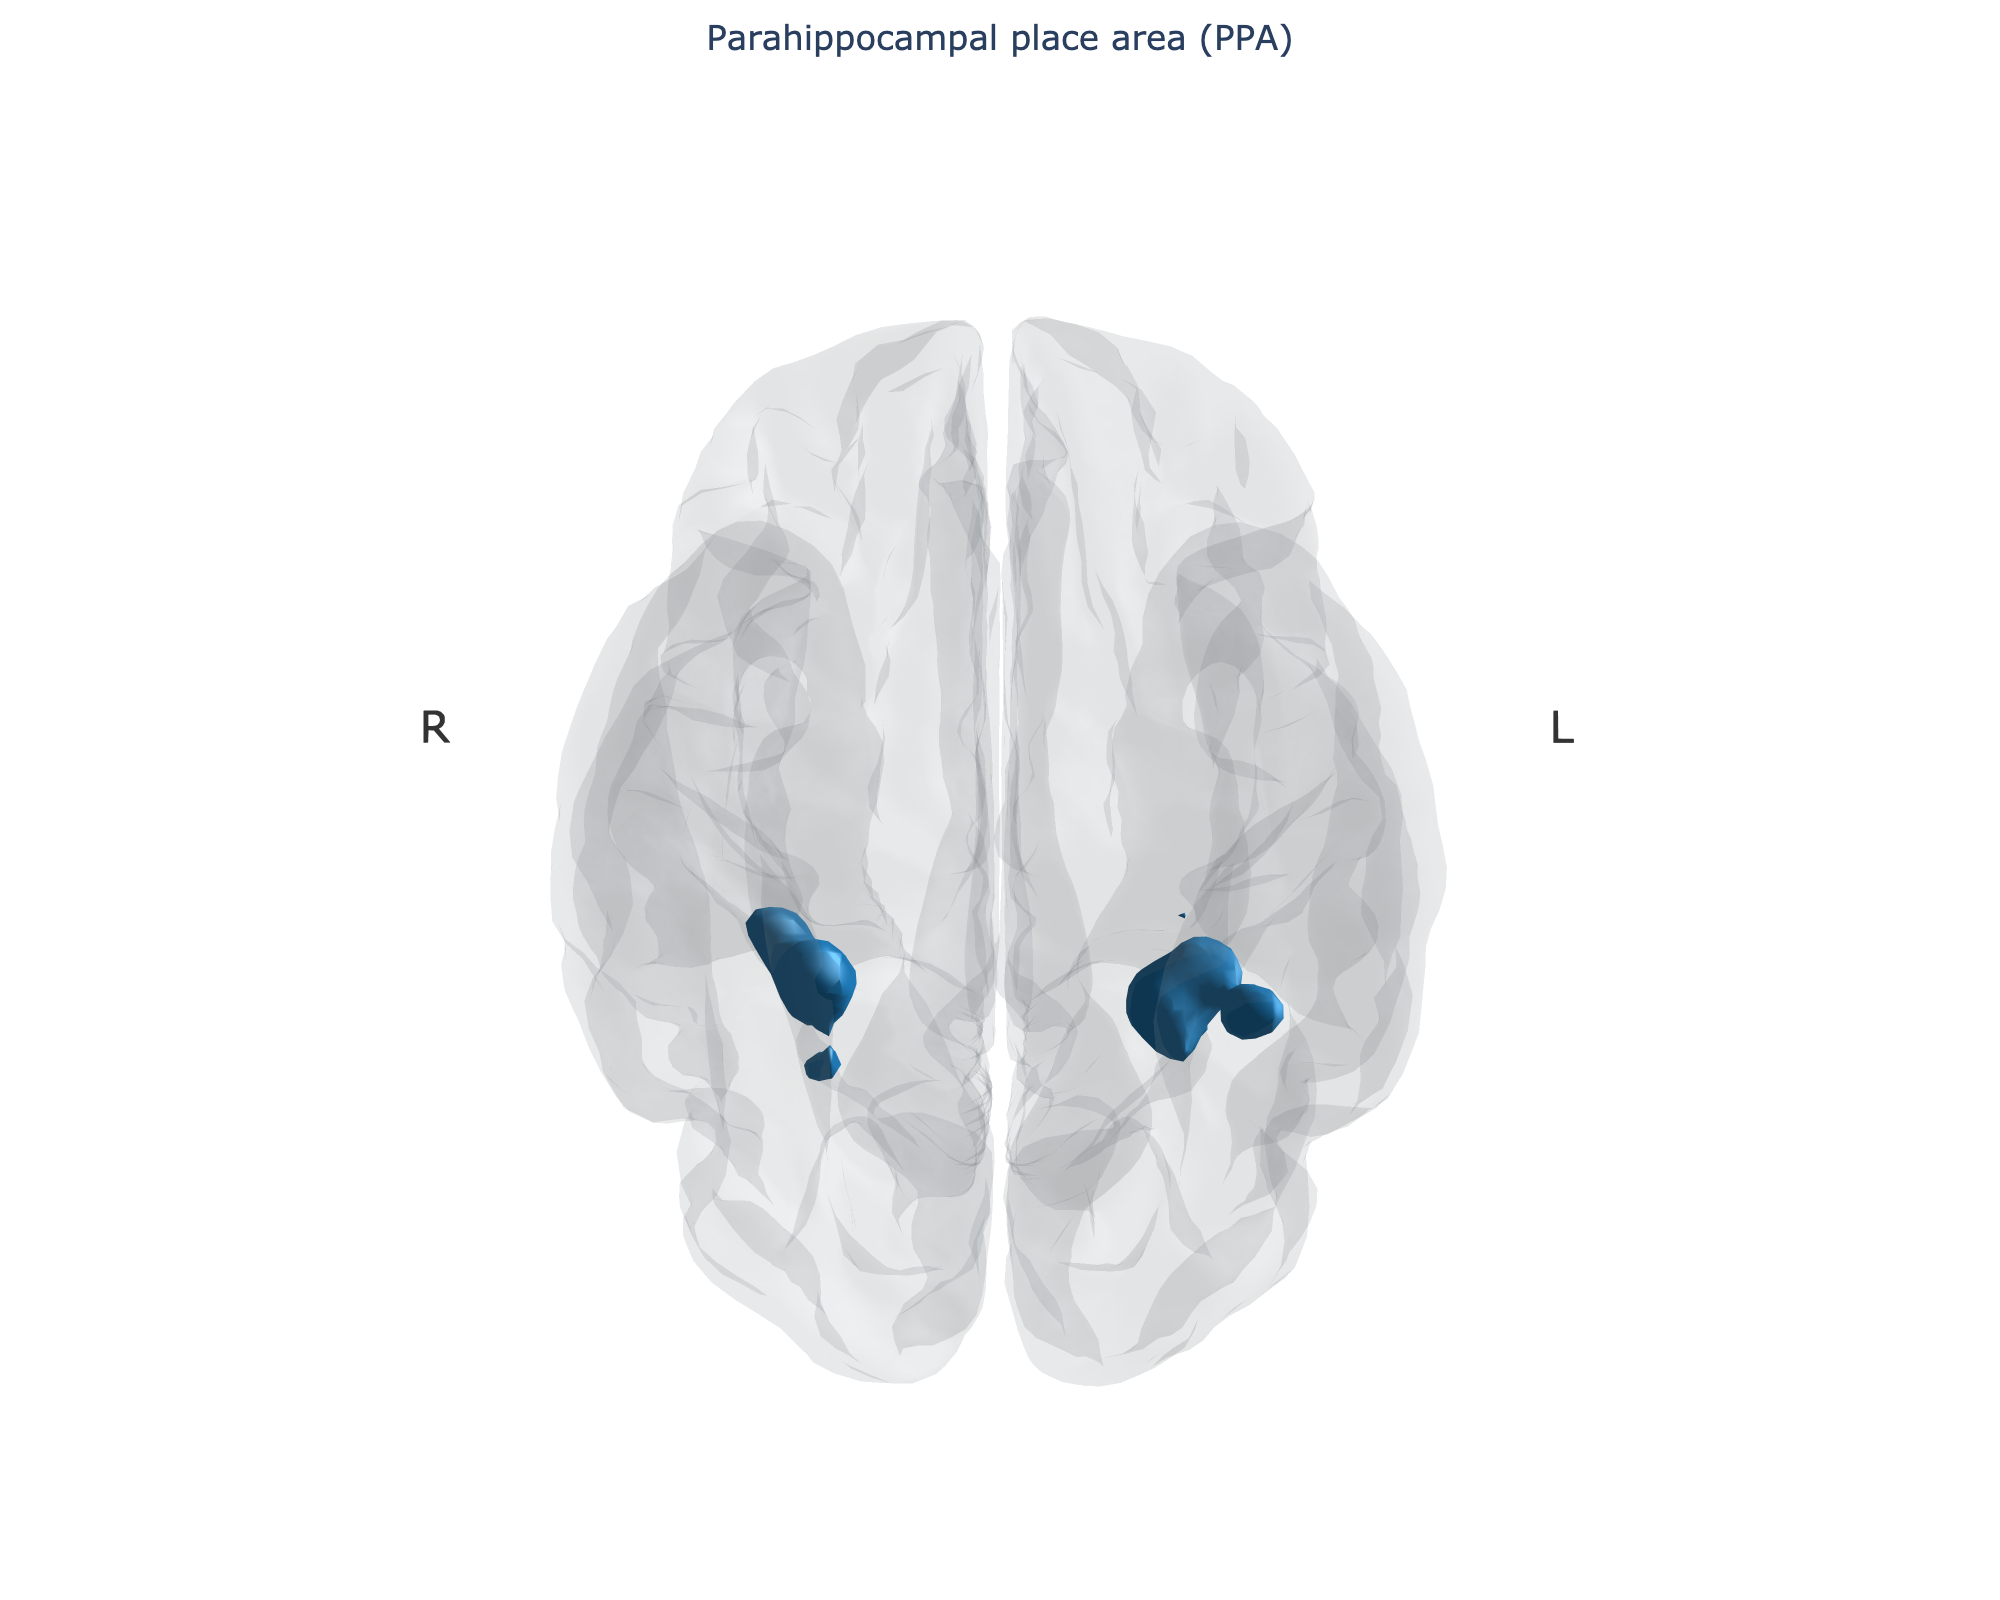

PPA glass-brain figures written


In [6]:
GLASS = datasets.load_fsaverage(mesh="fsaverage5")

def smooth_isosurface(mask, affine, sigma=1.0):
    vol = ndimage.gaussian_filter(mask.astype(float), sigma)
    v, f, _, _ = measure.marching_cubes(vol, level=0.5)
    return nib.affines.apply_affine(affine, v), f

def mesh_trace(v, f, **kw):
    return go.Mesh3d(x=v[:, 0], y=v[:, 1], z=v[:, 2], i=f[:, 0], j=f[:, 1], k=f[:, 2], hoverinfo="skip", **kw)

def glass_brain_figure(name, img, mask, thr, color, ctx_color=None, title=None):
    fig = go.Figure()
    for part in ("left", "right"):
        m = GLASS["pial"].parts[part]
        fig.add_trace(mesh_trace(m.coordinates, m.faces, color="#9aa0a6", opacity=0.10, lighting=dict(ambient=0.7, diffuse=0.5, specular=0.05), name=f"cortex {part}"))
    if ctx_color is not None:
        rest = (img.get_fdata() > thr) & ~mask
        if rest.sum() > 30:
            v, f = smooth_isosurface(rest, img.affine)
            fig.add_trace(mesh_trace(v, f, color=ctx_color, opacity=0.35, name="other suprathreshold clusters"))
    v, f = smooth_isosurface(mask, img.affine)
    fig.add_trace(mesh_trace(v, f, color=color, opacity=1.0, name=name, lighting=dict(ambient=0.45, diffuse=0.85, specular=0.35, roughness=0.4, fresnel=0.1)))
    fig.add_trace(go.Scatter3d(x=[-78, 78], y=[-20, -20], z=[-45, -45], mode="text", text=["L", "R"], textfont=dict(size=22, color="#333"), hoverinfo="skip", showlegend=False))
    fig.update_layout(width=1000, height=800, title=dict(text=title or name, x=0.5), showlegend=False, paper_bgcolor="white", margin=dict(l=0, r=0, t=50, b=0),
                      scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False, aspectmode="data"))
    return fig

VIEWS = {"ventral": dict(eye=dict(x=0.0, y=-0.35, z=-1.9), up=dict(x=0, y=1, z=0)),
         "oblique": dict(eye=dict(x=1.4, y=-1.1, z=-1.1), up=dict(x=0, y=0, z=1))}

for name, r in REGIONS.items():
    full = {"FFA": "Fusiform face area (FFA)", "PPA": "Parahippocampal place area (PPA)"}[name]
    for suffix, ctx in (("", None), ("_with_context", r["ctx_color"])):
        fig = glass_brain_figure(name, maps[name], masks[name], r["thr"], r["color"], ctx, title=full + ("  +  other clusters of the same map" if ctx else ""))
        fig.write_html(os.path.join(FIG_DIR, f"{name}_glass_brain{suffix}.html"), include_plotlyjs="cdn")
        for view, cam in VIEWS.items():
            fig.update_layout(scene_camera=cam)
            fig.write_image(os.path.join(FIG_DIR, f"{name}_glass_brain{suffix}_{view}.png"), scale=2)
        fig.update_layout(scene_camera=VIEWS["ventral"])
        if suffix == "":
            if INTERACTIVE:
                fig.show()
            else:
                display(Image(os.path.join(FIG_DIR, f"{name}_glass_brain_ventral.png"), width=700))
    print(name, "glass-brain figures written")

## 5. Inflated cortical surface

The z-map is sampled between the white and pial surfaces of fsaverage and shown on the inflated surface from below.
The PPA sits in the collateral sulcus, so it looks smaller on an inflated surface than in the volume. Each hemisphere is
rendered separately so the labeling is unambiguous.

[load_fsaverage] Dataset found in /Users/alexmaier/nilearn_data/fsaverage6


[load_fsaverage_data] Dataset found in /Users/alexmaier/nilearn_data/fsaverage6


[load_fsaverage_data] Dataset found in /Users/alexmaier/nilearn_data/fsaverage6


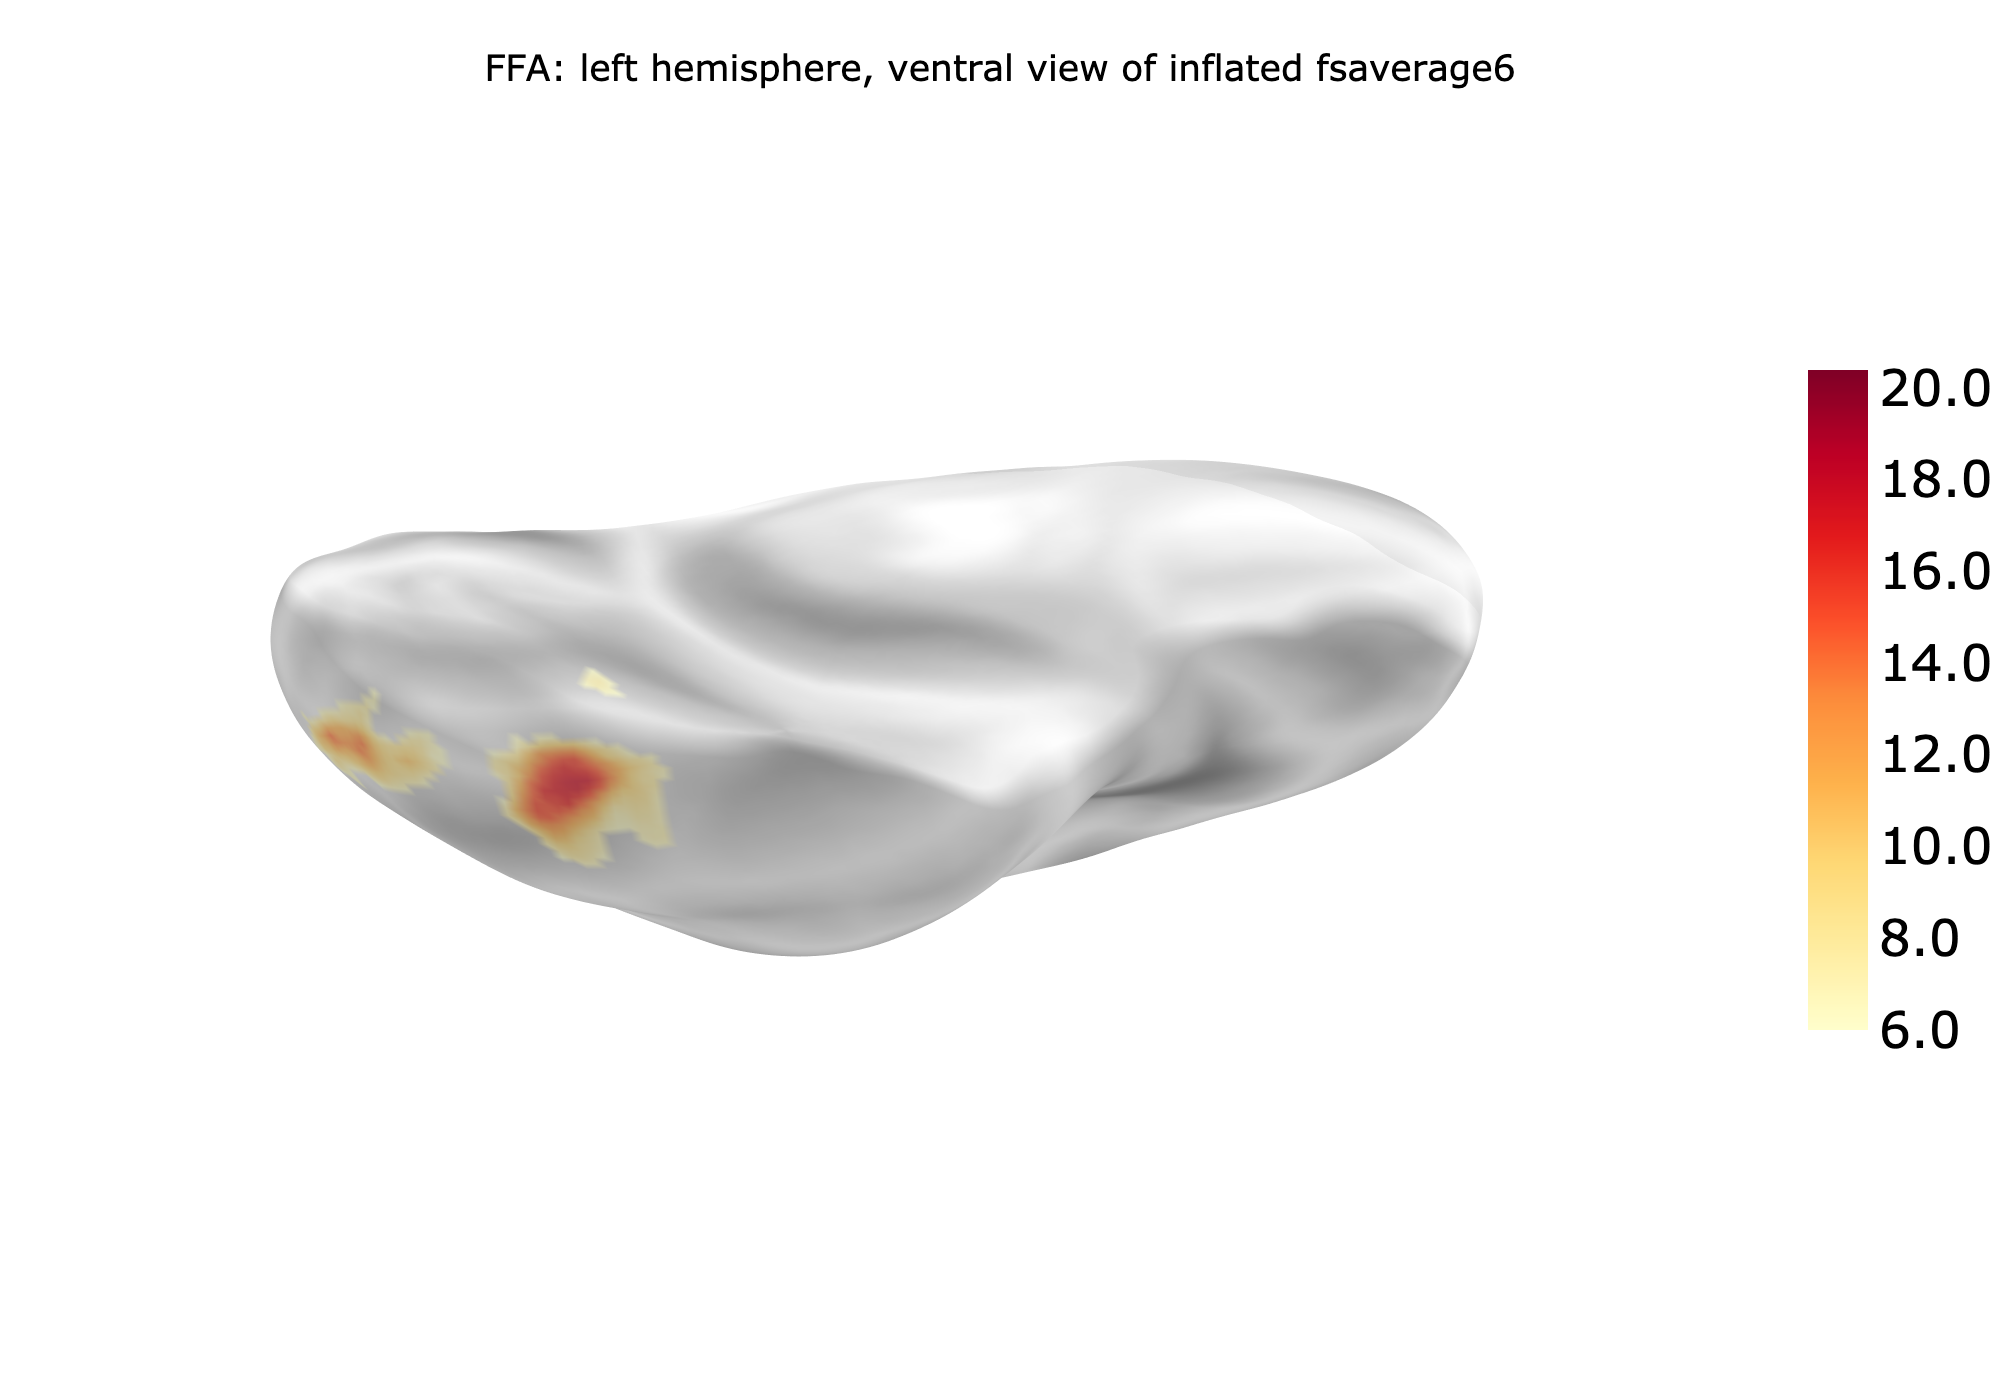

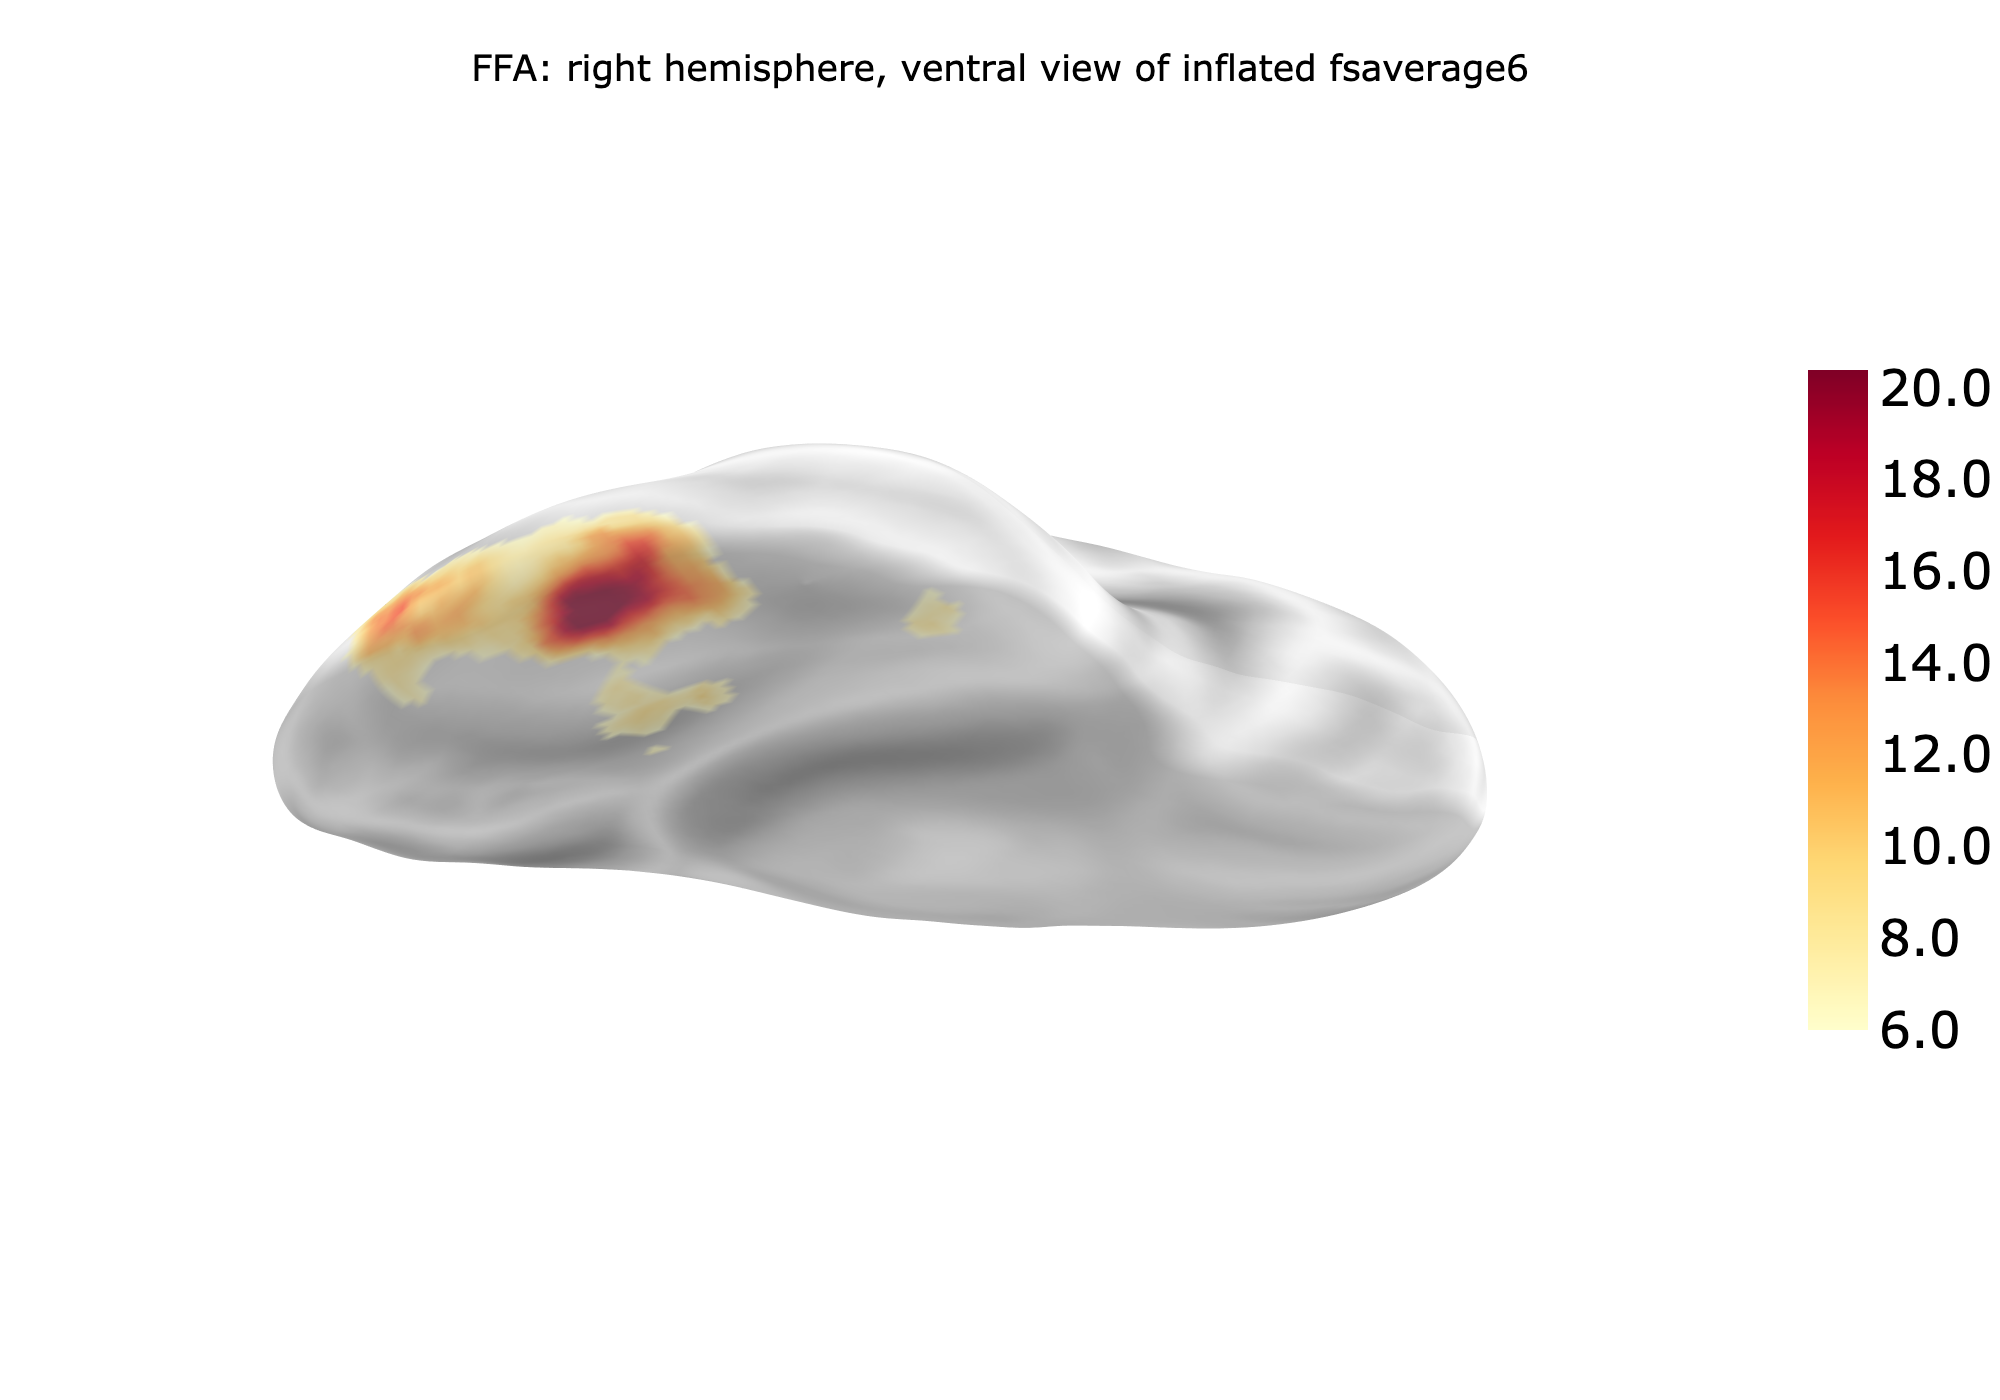

FFA surface figures written


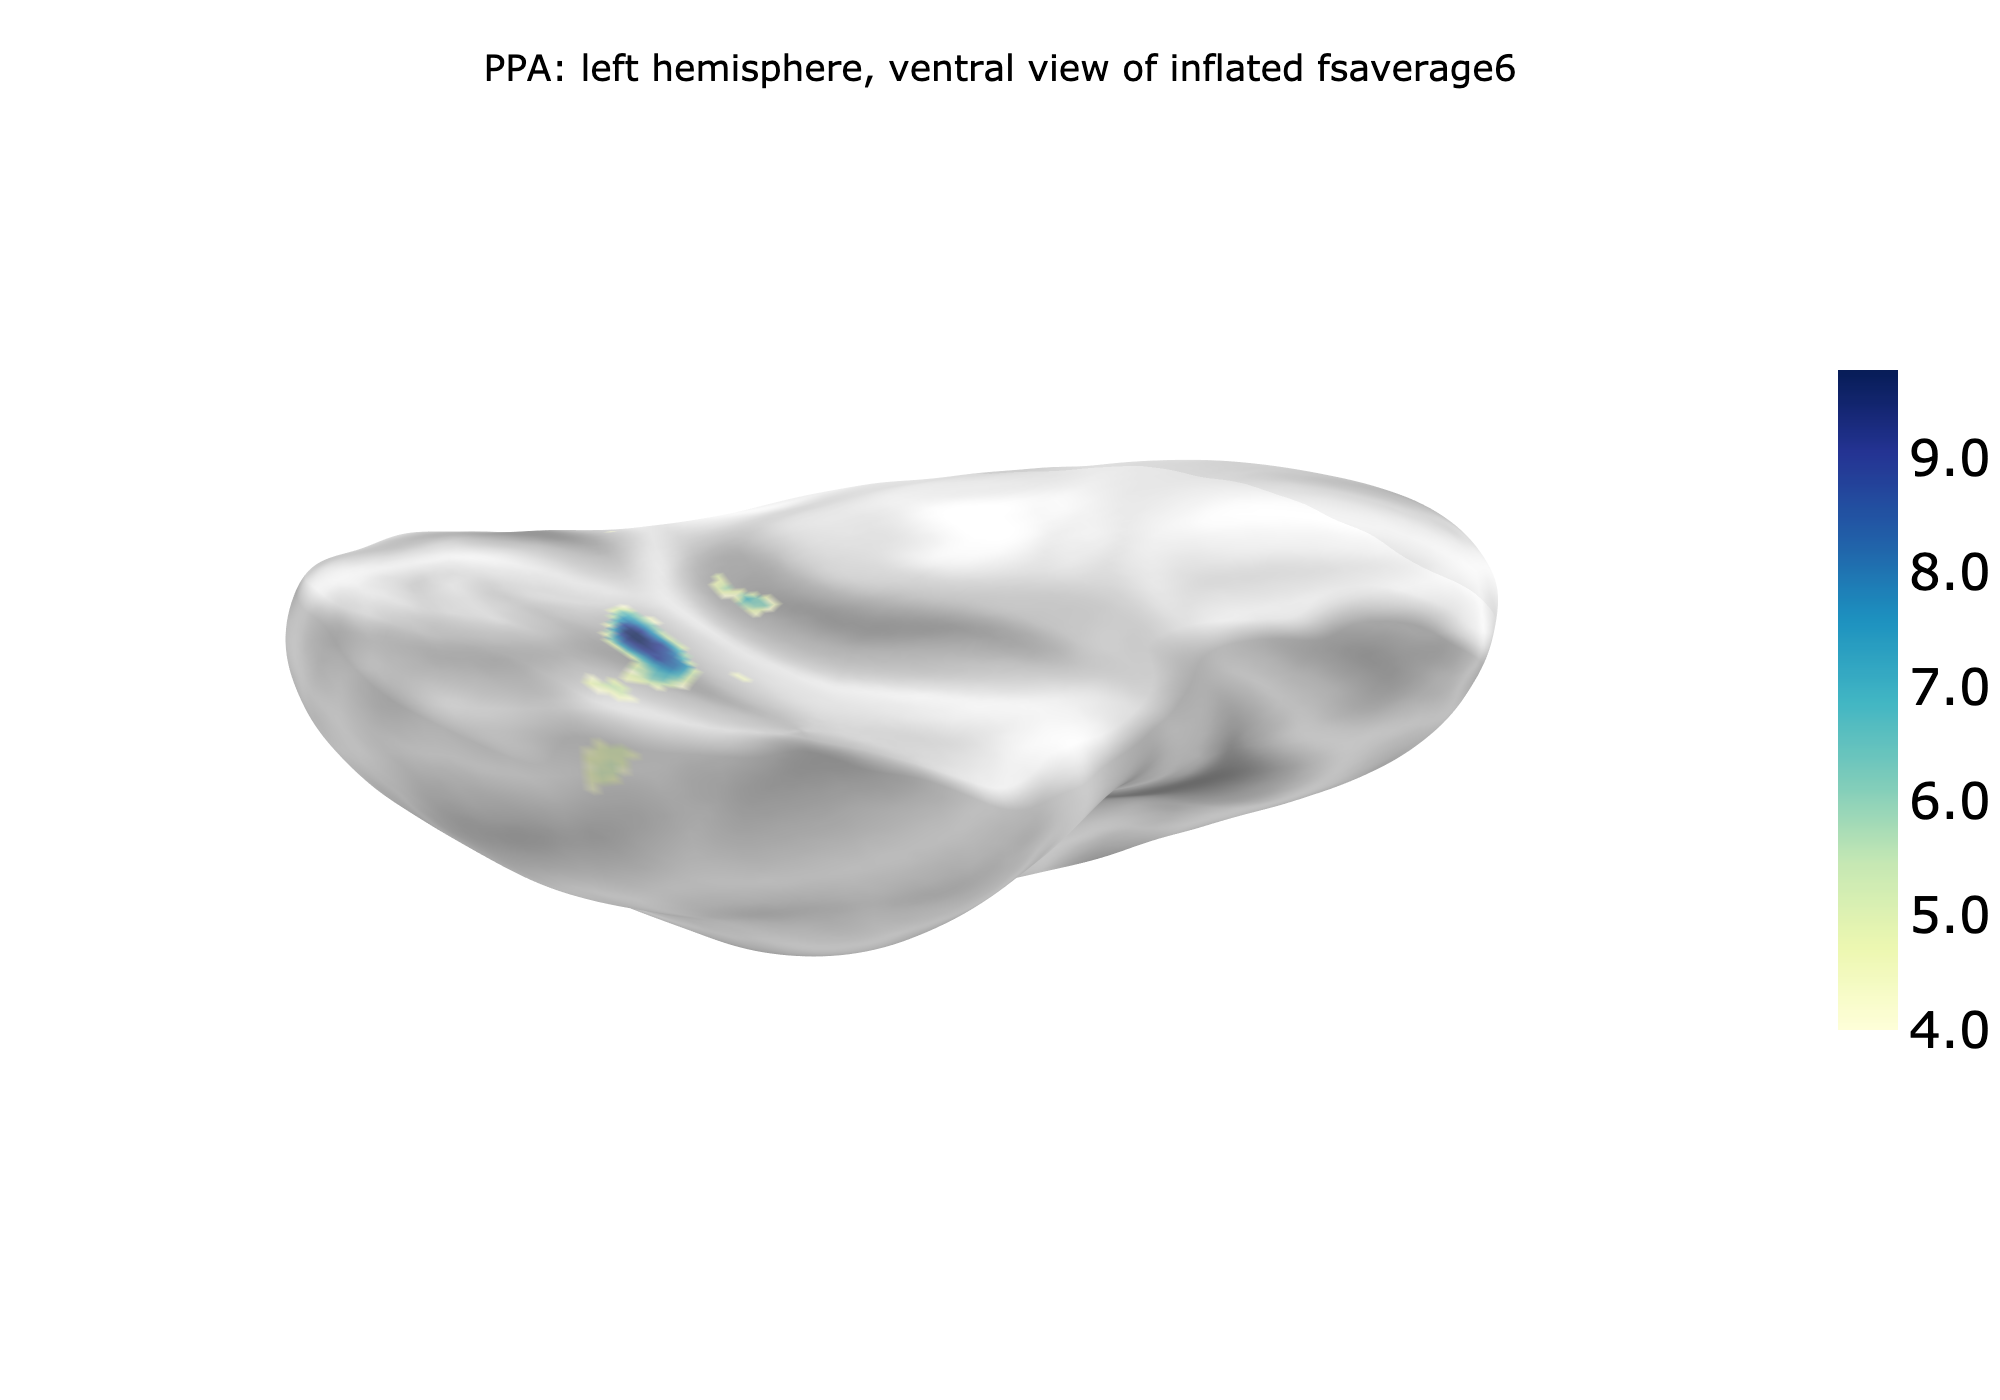

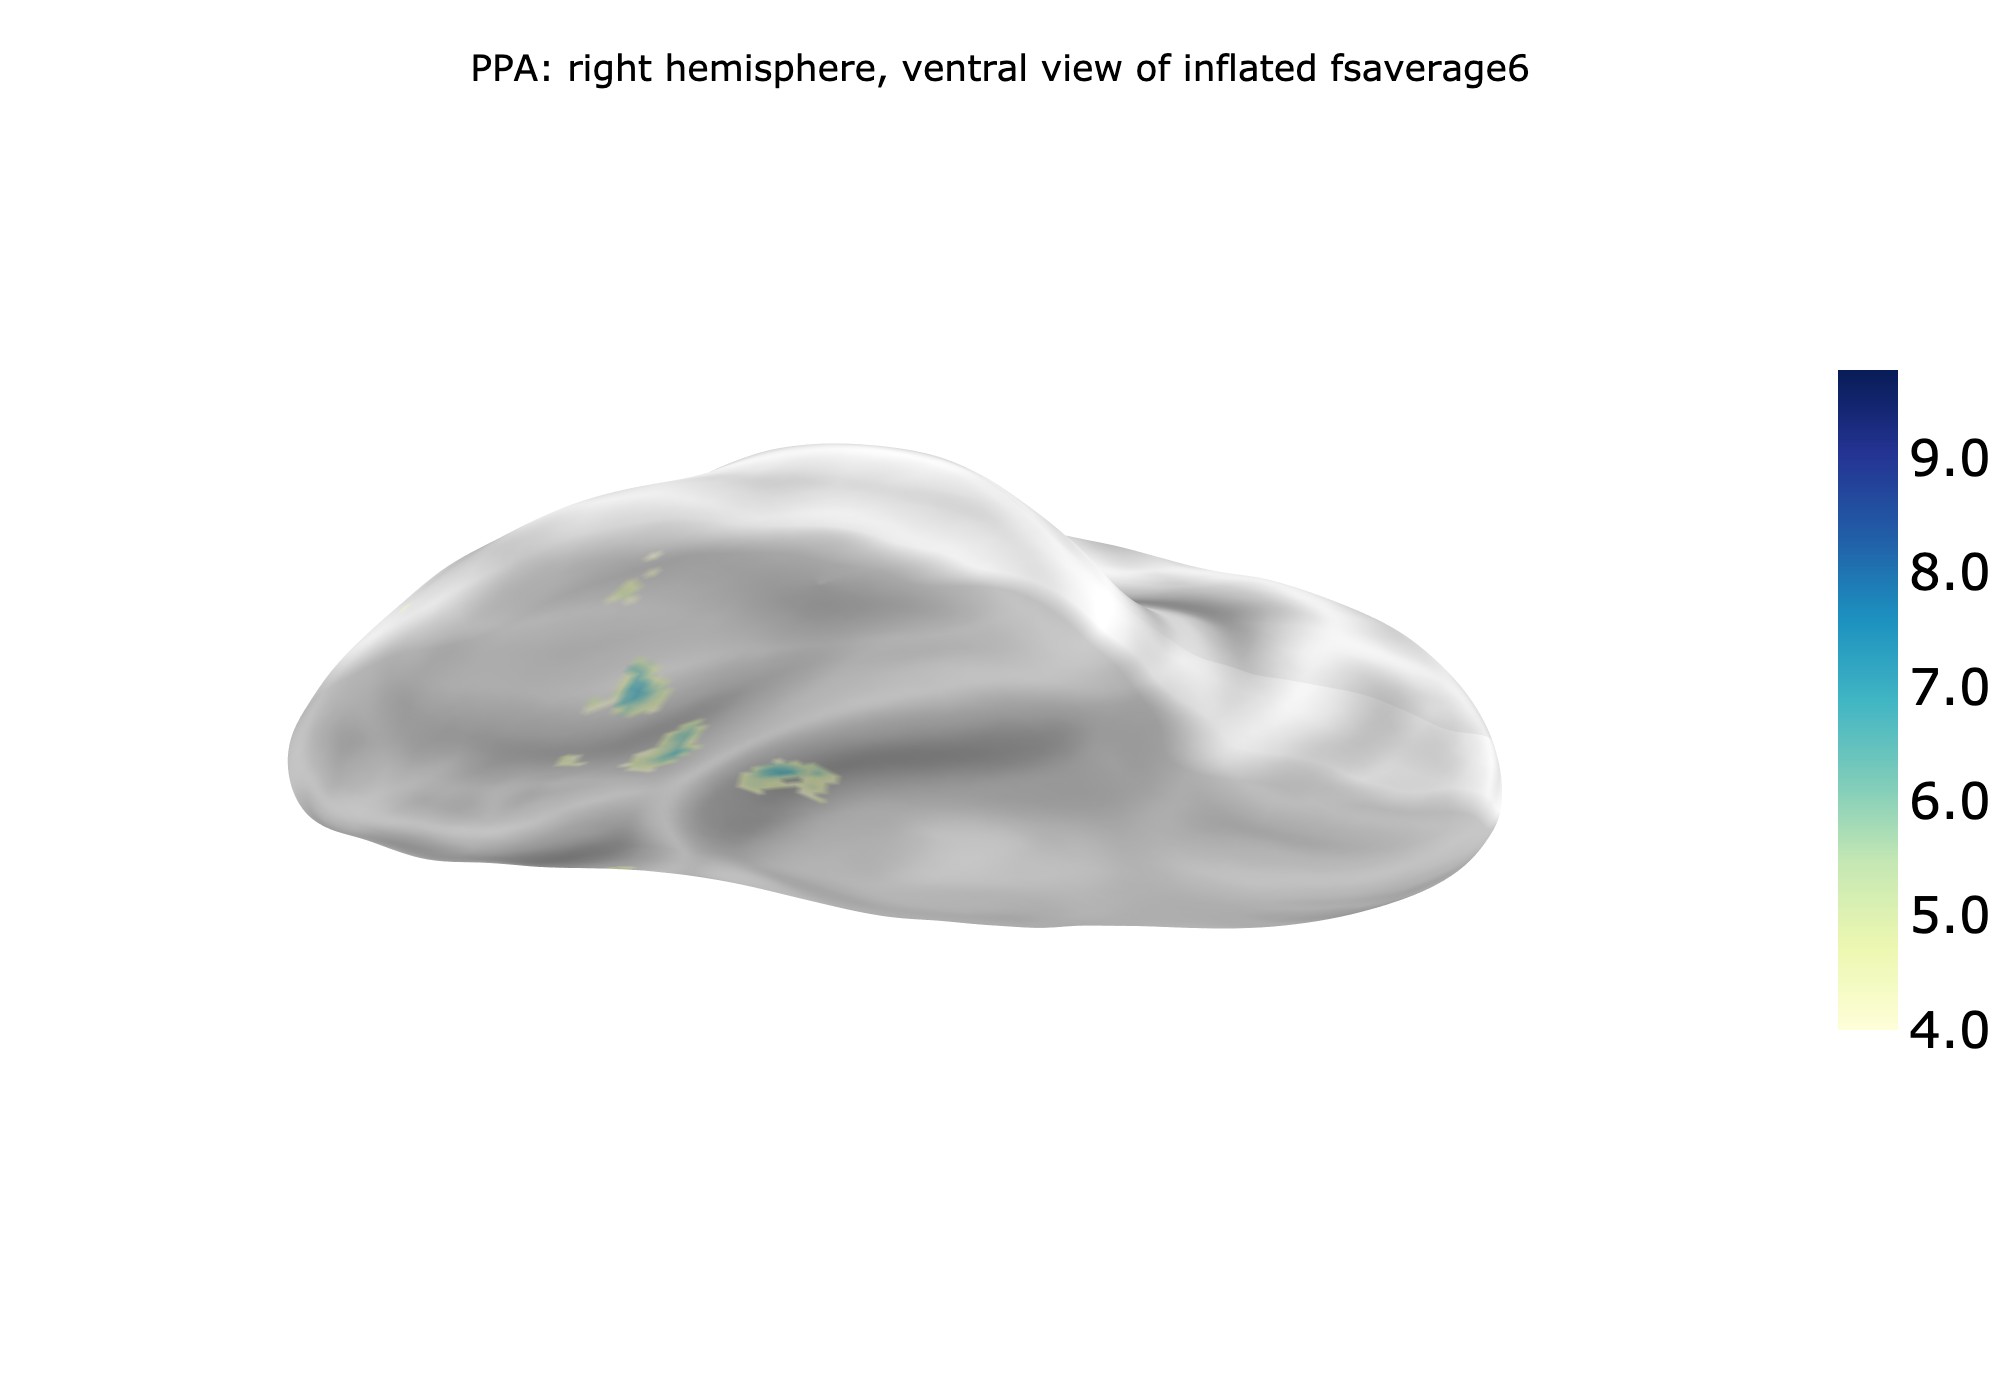

PPA surface figures written


In [7]:
fs = datasets.load_fsaverage(mesh=SURF_MESH)
sulc = datasets.load_fsaverage_data(mesh=SURF_MESH, data_type="sulcal")

for name, r in REGIONS.items():
    img = maps[name]
    surf = SurfaceImage.from_volume(mesh=fs["pial"], volume_img=img, inner_mesh=fs["white_matter"])
    vmax = float(np.percentile(img.get_fdata()[img.get_fdata() > 0], 99.5))
    for hemi in ("left", "right"):
        pf = plotting.plot_surf_stat_map(fs["inflated"], surf, bg_map=sulc, hemi=hemi, view="ventral", threshold=r["thr"],
                                         cmap=r["cmap"], vmin=r["thr"], vmax=vmax, symmetric_cbar=False, bg_on_data=True,
                                         darkness=0.6, engine="plotly", title=f"{name}: {hemi} hemisphere, ventral view of inflated {SURF_MESH}")
        cam = pf.figure.layout.scene.camera.eye   # pull the camera back so the whole hemisphere fits
        pf.figure.update_layout(width=1000, height=700, scene_camera_eye=dict(x=cam.x * 1.45, y=cam.y * 1.45, z=cam.z * 1.45))
        out = os.path.join(FIG_DIR, f"{name}_inflated_{hemi}_ventral.png")
        pf.figure.write_image(out, scale=2)
        display(Image(out, width=600))
    print(name, "surface figures written")

## 6. Outputs and how to attribute

Everything in `FIG_DIR` can be released as CC0. A caption along these lines is accurate and sufficient:

> Location of the fusiform face area (red) / parahippocampal place area (blue), defined as the largest cluster per hemisphere in the
> Neurosynth association-test map for the term "fusiform face" / "place" (FDR q < 0.01), rendered on the FreeSurfer fsaverage
> surface in MNI space. Underlying data: Neurosynth (Yarkoni et al. 2011, Nat Methods), CC0.

The region masks in `DATA_DIR` (`*_mask_MNI152_2mm.nii.gz`) are 2 mm MNI152 NIfTI files that can be loaded in any other viewer
(MRIcroGL, FSLeyes, 3D Slicer) if you want a different rendering style.

In [8]:
for root, _, files in os.walk(OUT_DIR):
    for f in sorted(files):
        p = os.path.join(root, f); print(f"{os.path.getsize(p)/1e6:7.2f} MB  {os.path.relpath(p, OUT_DIR)}")

   1.87 MB  figures/FFA_glass_brain.html
   0.49 MB  figures/FFA_glass_brain_oblique.png
   0.63 MB  figures/FFA_glass_brain_ventral.png
   1.90 MB  figures/FFA_glass_brain_with_context.html
   0.50 MB  figures/FFA_glass_brain_with_context_oblique.png
   0.65 MB  figures/FFA_glass_brain_with_context_ventral.png
   0.26 MB  figures/FFA_inflated_left_ventral.png
   0.28 MB  figures/FFA_inflated_right_ventral.png
   0.12 MB  figures/FFA_mni_slices.png
   1.81 MB  figures/PPA_glass_brain.html
   0.50 MB  figures/PPA_glass_brain_oblique.png
   0.63 MB  figures/PPA_glass_brain_ventral.png
   1.83 MB  figures/PPA_glass_brain_with_context.html
   0.51 MB  figures/PPA_glass_brain_with_context_oblique.png
   0.64 MB  figures/PPA_glass_brain_with_context_ventral.png
   0.25 MB  figures/PPA_inflated_left_ventral.png
   0.24 MB  figures/PPA_inflated_right_ventral.png
   0.12 MB  figures/PPA_mni_slices.png
   0.01 MB  data/FFA_mask_MNI152_2mm.nii.gz
   0.00 MB  data/PPA_mask_MNI152_2mm.nii.gz
   0.1